#  Exploratory Data Analysis




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../dataset/train.csv')

## Dataset Overview

In [3]:
print(df.shape)
print(df.info())
print(df.head())

(690088, 15)
<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  ge

## Missing value Analysis

stress_level               82811
sleep_duration             75999
sleep_quality              58331
calorie_expenditure        52853
water_intake               43477
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
step_count                 13916
bmi                        13898
heart_rate                  7833
diet_type                   6901
exercise_duration           6901
id                             0
health_condition               0
dtype: int64


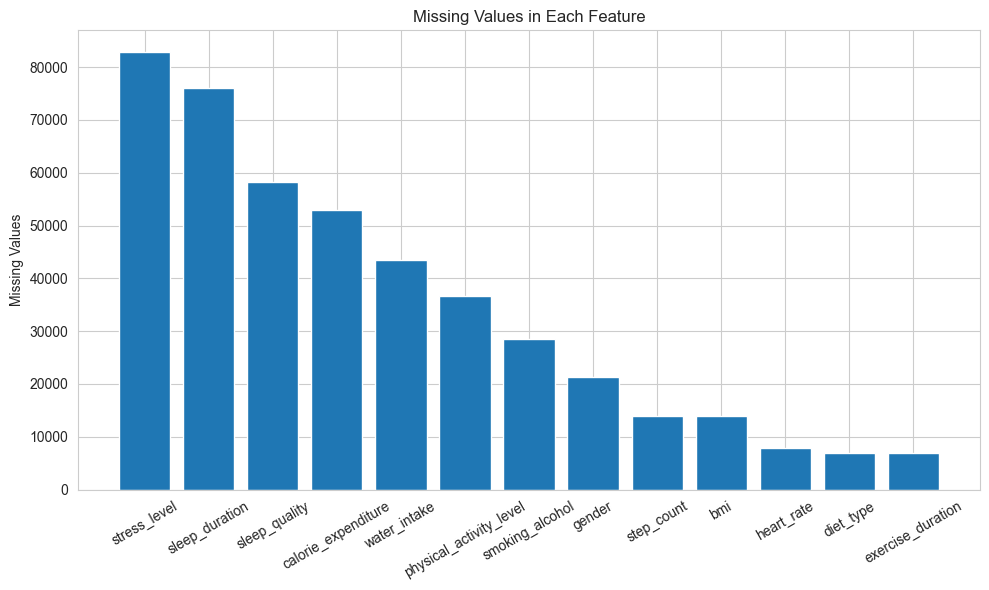

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

missing = missing[missing > 0]


plt.figure(figsize=(10,6))
plt.bar(missing.index, missing.values)
plt.xticks(rotation=30)
plt.ylabel("Missing Values")
plt.title("Missing Values in Each Feature")
plt.tight_layout()
plt.show()



## Target Variable Distribution


health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64


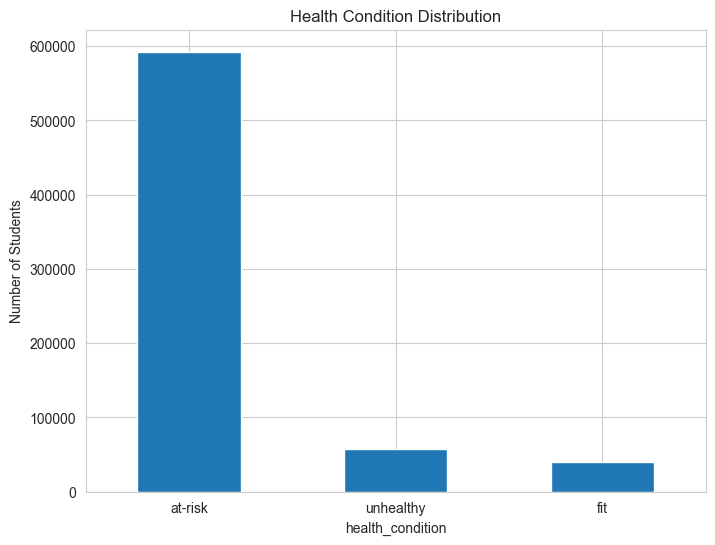

In [5]:
print(df["health_condition"].value_counts())


plt.figure(figsize=(8,6))
df["health_condition"].value_counts().plot(
    kind="bar",
    rot=0
)

plt.title("Health Condition Distribution")
plt.ylabel("Number of Students")
plt.show()

## Numerical feature distributions

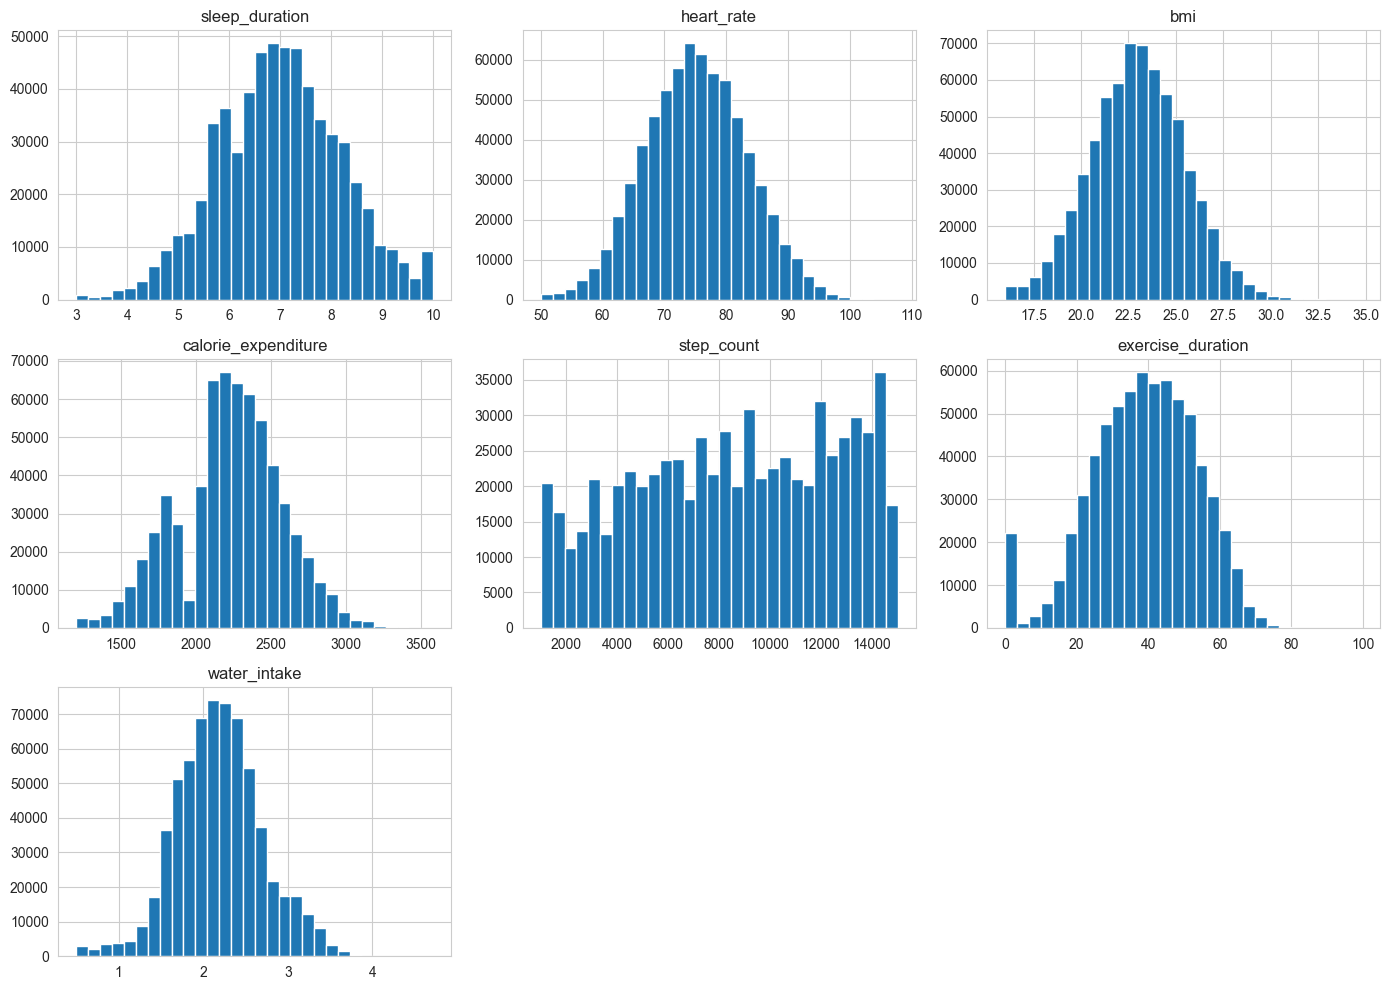

In [6]:
numeric_columns = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

df[numeric_columns].hist(
    figsize=(14,10),
    bins=30
)

plt.tight_layout()
plt.show()

## Categorical feature Distribution

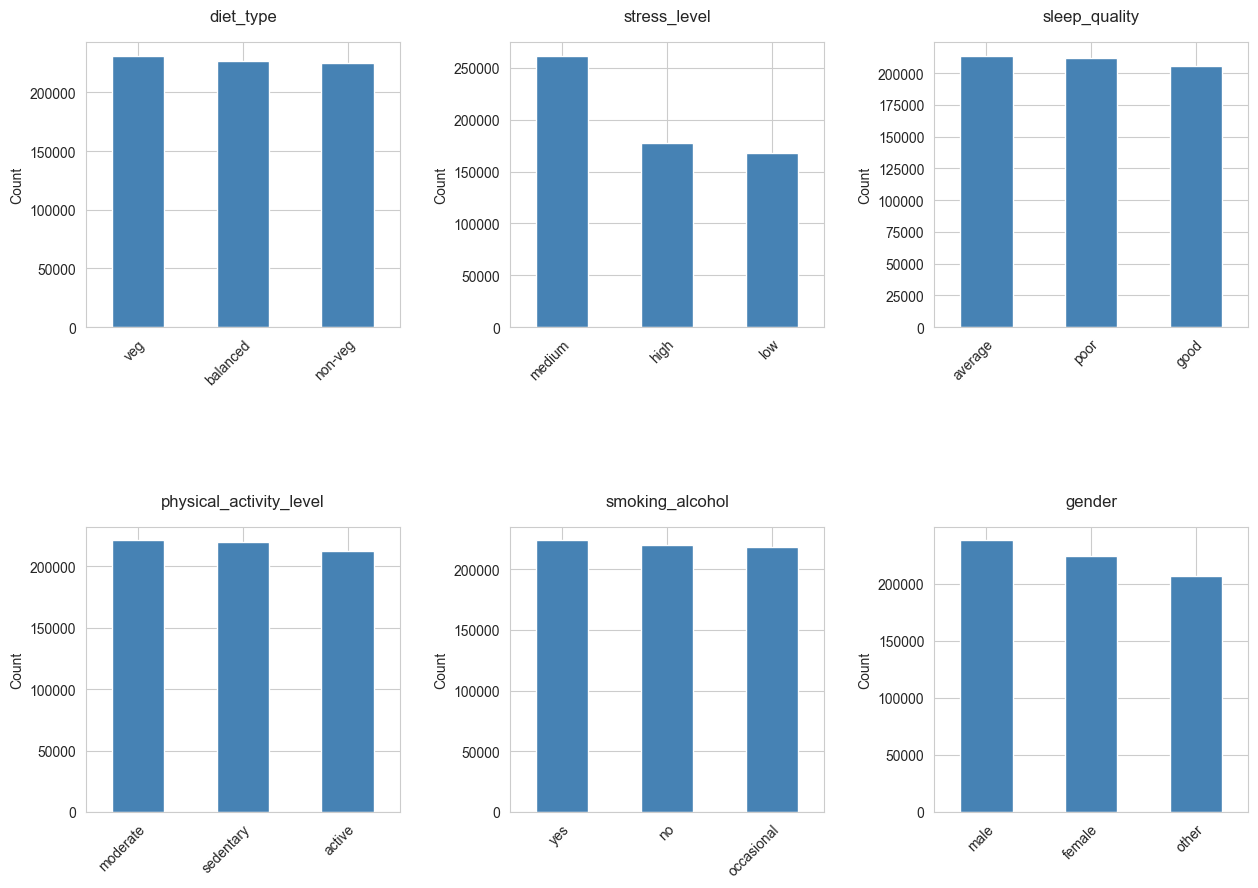

In [7]:
categorical_columns = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]


import math
import matplotlib.pyplot as plt

# 1. Setup grid dimensions
n_cols = 3
n_rows = math.ceil(len(categorical_columns) / n_cols)

# Make the figure taller (5 inches per row) for extra space
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

# 2. Plot data
for i, col in enumerate(categorical_columns):
    # Plot bars directly
    df[col].value_counts().plot(kind="bar", ax=axes[i], color="steelblue")
    
    # --- FIX 1: Explicitly clear X-label and set Title above ---
    axes[i].set_xlabel("")                        # Clears any default x-axis label
    axes[i].set_title(col, fontsize=12, pad=15)   # Title cleanly ABOVE the plot
    
    # --- FIX 2: Explicitly add Y-axis label ---
    axes[i].set_ylabel("Count", fontsize=10)      # Adds 'Count' to the y-axis
    
    # Fix tick label rotation and alignment
    axes[i].set_xticklabels(
        axes[i].get_xticklabels(), 
        rotation=45, 
        ha="right", 
        rotation_mode="anchor"
    )

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# --- FIX 3: Massive vertical spacing so nothing overlaps ---
plt.subplots_adjust(
    hspace=0.7,  # Vertical space between top and bottom plots
    wspace=0.35  # Horizontal space between left and right plots
)

plt.show()

## Correlation Matrix (numeric features)

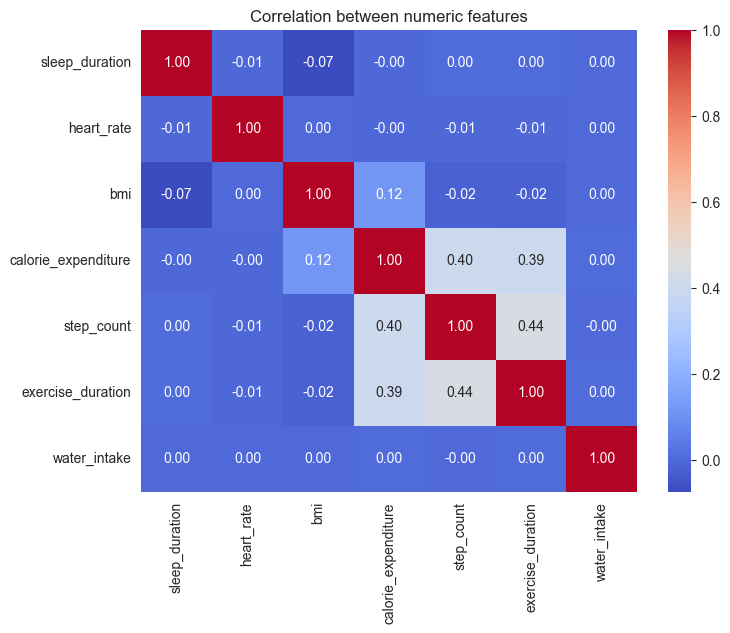

In [8]:
numeric_columns = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between numeric features')
plt.show()

## Numeric Features vs. Target Class

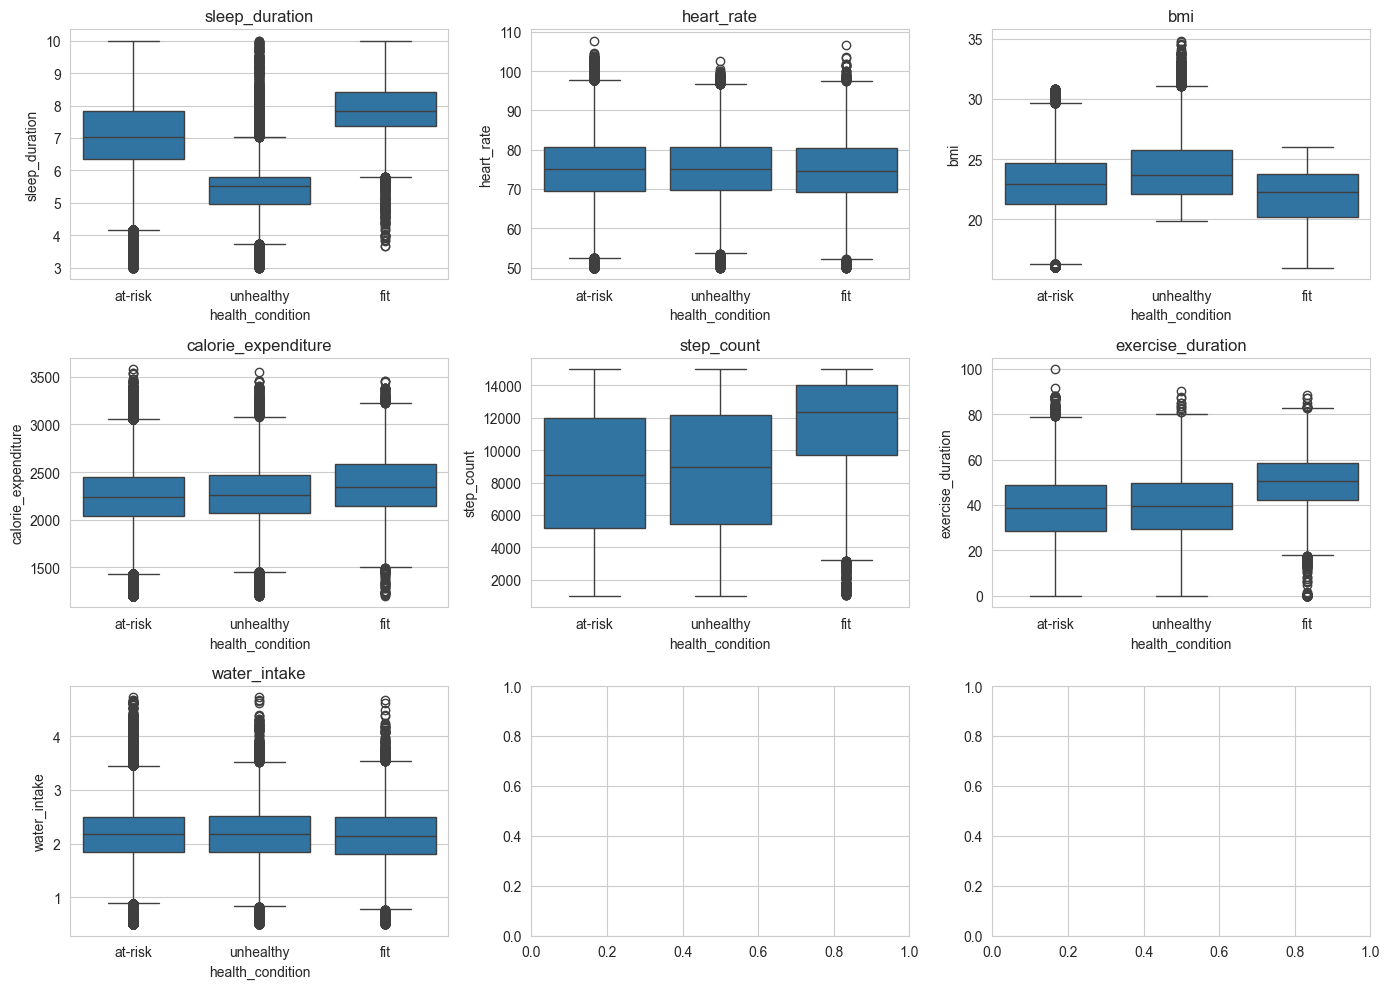

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), numeric_columns):
    sns.boxplot(data=df, x='health_condition', y=col, ax=ax,
                order=['at-risk','unhealthy','fit'])
    ax.set_title(col)
plt.tight_layout(); plt.show()

## Categorical Features vs. Target Class

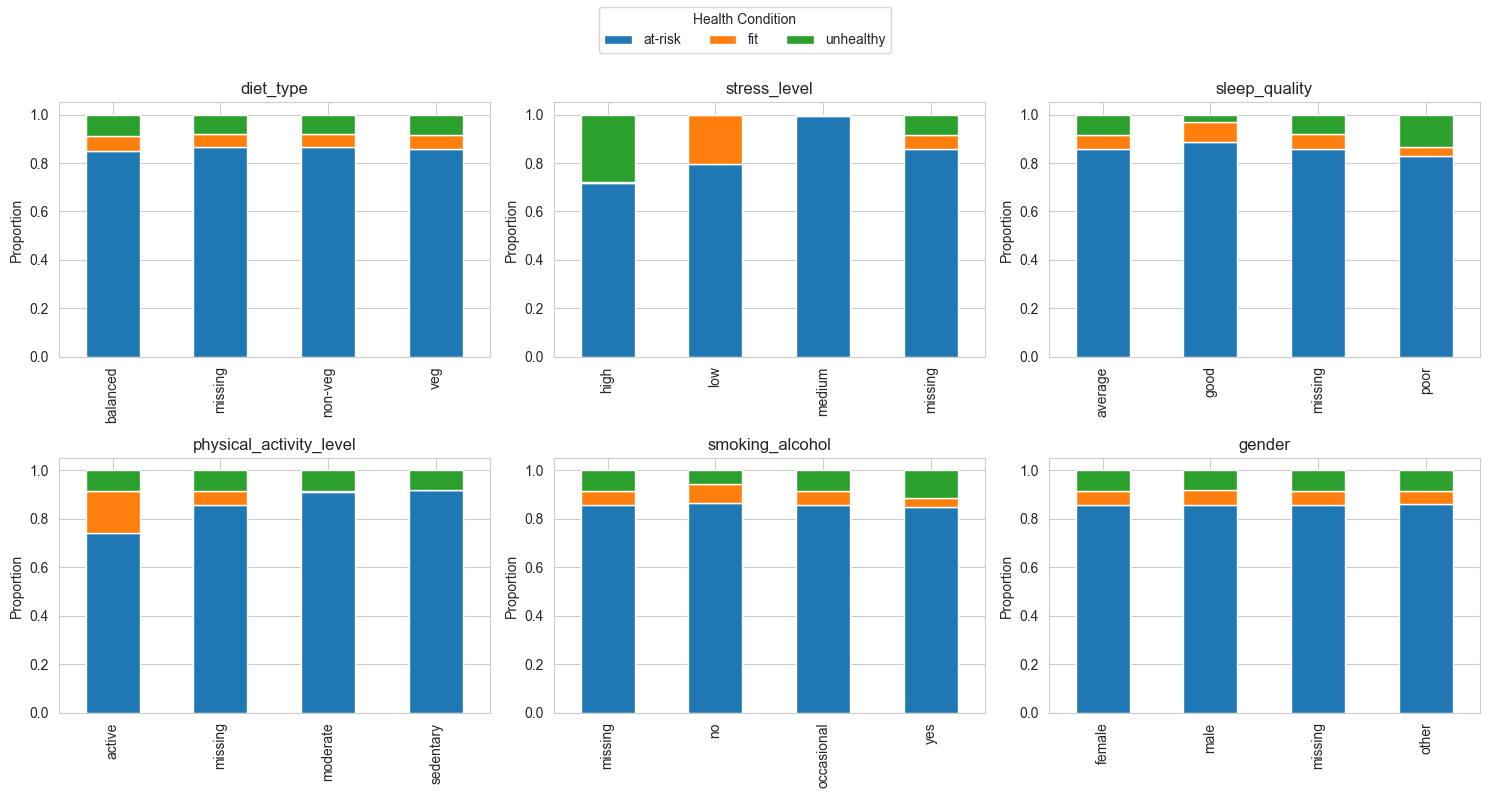

In [12]:

categorical_cols = [
    'diet_type',
    'stress_level',
    'sleep_quality',
    'physical_activity_level',
    'smoking_alcohol',
    'gender'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), categorical_cols):
    ct = pd.crosstab(
        df[col].fillna('missing'),
        df['health_condition'],
        normalize='index'
    )
    
    ct.plot(kind='bar', stacked=True, ax=ax, legend=False)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Proportion')

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Health Condition',
    loc='upper center',
    ncol=3
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()